<a href="https://colab.research.google.com/github/legong-beep/MPM_204_Gong/blob/main/assignments/04_Assignment_Mixed_Models_ALLdone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MPM 204 Assignment 4

## Due April 30th 2026 Midnight

#### For all questions, you must show your work. This will enable us to understand your thought process, give partial credit, and prevent crude cheating.
#### Please make sure that you are not simply copying each other's code, but rather striving to understand each other's work and learn from it.
#### Additionally, please provide the R code at the end of your solution and include R commands along with R outputs. This will help to describe your solutions more clearly.

## Section 0

Load the required packages:
* for this specific assignment, you will need glmmTMB and bbmle, along with other packages that you routinely use.

In [1]:
install.packages("glmmTMB")
install.packages("bbmle")
library(glmmTMB)
library(bbmle)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘RcppArmadillo’, ‘rbibutils’, ‘cowplot’, ‘Deriv’, ‘forecast’, ‘microbenchmark’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘doBy’, ‘zoo’, ‘TMB’, ‘lme4’, ‘numDeriv’, ‘reformulas’, ‘pbkrtest’, ‘sandwich’, ‘RcppEigen’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘bdsmatrix’, ‘mvtnorm’


Loading required package: stats4



### Salamanders in Streams
* Repeated samples of salamanders were taken at 23 sites
* Some sites were affected by mountain top removal due to coal mining
* Originally published in Price e al. (2016)

In [2]:
data(Salamanders)
?Salamanders
head(Salamanders)

,site,mined,cover,sample,DOP,Wtemp,DOY,spp,count
,<ord>,<fct>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<fct>,<int>
1,VF-1,yes,-1.4423172,1,-0.5956834,-1.22937861,-1.497003,GP,0
2,VF-2,yes,0.2984104,1,-0.5956834,0.08476529,-1.497003,GP,0
3,VF-3,yes,0.3978806,1,-1.1913668,1.01417627,-1.294467,GP,0
4,R-1,no,-0.4476157,1,0.0000000,-3.02335795,-2.712216,GP,2
5,R-2,no,0.5968209,1,0.5956834,-0.14434533,-0.686860,GP,2
6,R-3,no,1.3428470,1,0.5956834,-0.01466007,-0.686860,GP,1


#### Q1: Find the data dictionary associated with the data and list the description of each variable.
Hint: This data comes from a library that you have already loaded. You can find more information about the data in the same way you find additional information about R commands.

Points: 1

ANSWERS:

Site: The name of the location where samples were taken

Mined: Whether the site was affected by mountaintop coal mining (yes/no)

Cover: Amount of cover objects in the stream (scaled)

Sample: which repeat sample it was at that site

DOP: days since last precipitation (scaled)

Wtemp: Water temperature (scaled)

DOY: day of the year (scaled)

spp: Salamander species (or life stage)

Count: number of salamanders counted ← your outcome variable



In [6]:
Salamanders = transform(Salamanders, present = as.numeric(count>0))
## this creates additional binary for presence and absence of Salamanders based on counts

In [4]:
head(Salamanders)

,site,mined,cover,sample,DOP,Wtemp,DOY,spp,count,present
,<ord>,<fct>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<fct>,<int>,<dbl>
1,VF-1,yes,-1.4423172,1,-0.5956834,-1.22937861,-1.497003,GP,0,0
2,VF-2,yes,0.2984104,1,-0.5956834,0.08476529,-1.497003,GP,0,0
3,VF-3,yes,0.3978806,1,-1.1913668,1.01417627,-1.294467,GP,0,0
4,R-1,no,-0.4476157,1,0.0000000,-3.02335795,-2.712216,GP,2,1
5,R-2,no,0.5968209,1,0.5956834,-0.14434533,-0.686860,GP,2,1
6,R-3,no,1.3428470,1,0.5956834,-0.01466007,-0.686860,GP,1,1


#### Q2 Complete the `ggplot` code to explore the outcome of interest vs species and the presence of mining
Points: 3

In [5]:
install.packages("ggplot2")
library(ggplot2)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


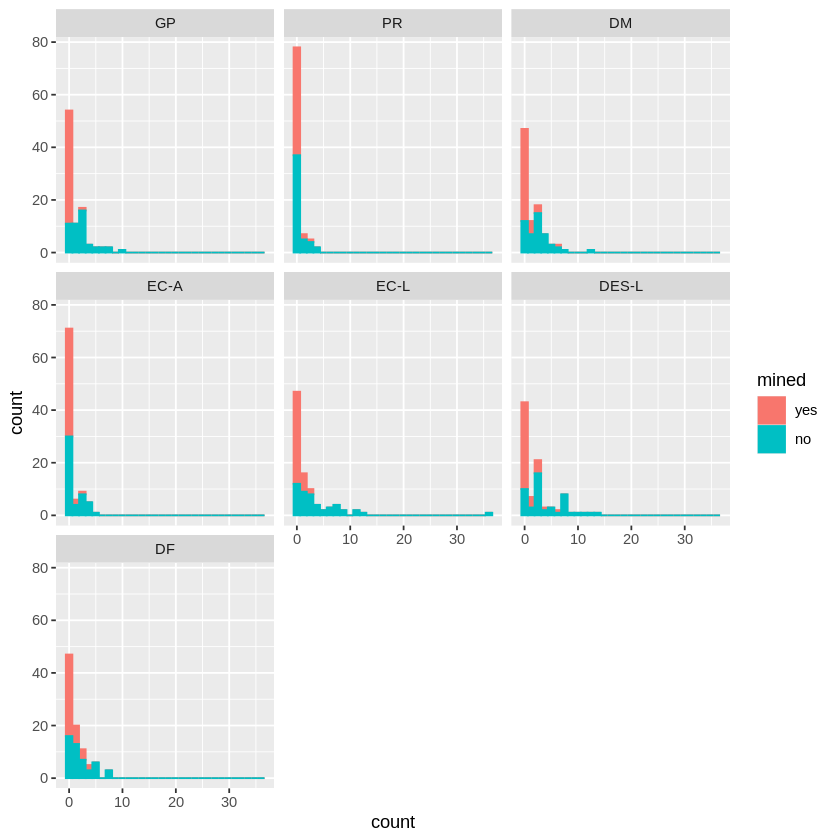

In [7]:
p <- ggplot(data = Salamanders, aes(x = count, color=mined, fill=mined)) + geom_histogram()
p + facet_wrap(~spp)
## hint color and fill argument will take the same column/variable

## Section 2: Model fitting with `glmmTMB`

* The syntax for fitting GLMMs with `glmmTMB` is quite similar to using `glmer`.

#### Q3 fit following models
1. Model with species as a fixed effect.
2. Another model with species and mining as fixed effects.
3. For both models, decide which variable you will choose as a random effect for the intercept and include it in the formula.
4. Use the Poisson distribution.
5. Run an `anova` test to check if the fuller model has a higher likelihood.  
Points 10

In [8]:
pm1 = glmmTMB(count ~ spp + (1|site), Salamanders, family=poisson)
pm2 = glmmTMB(count ~ spp + mined + (1|site), Salamanders, family=poisson)
anova(pm1, pm2)

,Df,AIC,BIC,logLik,deviance,Chisq,Chi Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
pm1,8,1992.655,2028.396,-988.3274,1976.655,NA,NA,NA
pm2,9,1962.807,2003.017,-972.4037,1944.807,31.84731,1,1.667803e-08


pm2 is better than pm1 with a lower AIC, and lower p-value. This indicates mining significantly improves the model compared to species alone

#### Q4 Run a model generated with a binomial column (presence/absence) as the outcome and see if the same covariates are statistically significant.
1. Model with species as a fixed effect.
2. Another model with species and mining as fixed effects.
3. For both models, decide which variable you will choose as a random effect for the intercept and include it in the formula.
4. Use the Binomial distribution.
5. Describe the comparison specifically regarding covariates that are significant in the Poisson and Binomial models.

Points 5

ANSWERS:

Chose site as random effect for the intercept because salamanders were sampled repeatedly at the same 23 sites. This accounts for any clustering and allows each site to have its own baseline.

In both models, minedno is very significant, indicating it affects the count of salamanders and their status. More species are significant in the Poisson model compared to the binomial model. Species was another sigificant covariate in both models, with more species having more significances in the Poisson model.

In [9]:
b1 = glmmTMB(present ~ spp + (1|site), Salamanders, family=binomial)
b2 = glmmTMB(present ~ spp + mined + (1|site), Salamanders, family=binomial)

In [10]:
summary(b2)

 Family: binomial  ( logit )
Formula:          present ~ spp + mined + (1 | site)
Data: Salamanders

      AIC       BIC    logLik -2*log(L)  df.resid 
    640.8     681.0    -311.4     622.8       635 

Random effects:

Conditional model:
 Groups Name        Variance Std.Dev.
 site   (Intercept) 0.5483   0.7405  
Number of obs: 644, groups:  site, 23

Conditional model:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)  -1.9740     0.3809  -5.183 2.18e-07 ***
sppPR        -1.8244     0.4152  -4.394 1.11e-05 ***
sppDM         0.4678     0.3669   1.275   0.2023    
sppEC-A      -1.2045     0.3859  -3.122   0.0018 ** 
sppEC-L       0.4678     0.3669   1.275   0.2023    
sppDES-L      0.7378     0.3695   1.997   0.0458 *  
sppDF         0.4678     0.3669   1.275   0.2023    
minedno       2.6766     0.3903   6.858 6.96e-12 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [11]:
summary(pm2)

 Family: poisson  ( log )
Formula:          count ~ spp + mined + (1 | site)
Data: Salamanders

      AIC       BIC    logLik -2*log(L)  df.resid 
   1962.8    2003.0    -972.4    1944.8       635 

Random effects:

Conditional model:
 Groups Name        Variance Std.Dev.
 site   (Intercept) 0.3316   0.5759  
Number of obs: 644, groups:  site, 23

Conditional model:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept) -1.62490    0.24048  -6.757 1.41e-11 ***
sppPR       -1.38626    0.21516  -6.443 1.17e-10 ***
sppDM        0.23054    0.12889   1.789   0.0737 .  
sppEC-A     -0.77010    0.17105  -4.502 6.73e-06 ***
sppEC-L      0.62118    0.11931   5.207 1.92e-07 ***
sppDES-L     0.67918    0.11813   5.750 8.95e-09 ***
sppDF        0.08005    0.13344   0.600   0.5486    
minedno      2.26444    0.28026   8.080 6.48e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

## Section 3: Negative Binomial

#### Q5: Why would you consider a negative binomial model?
* Support your decision using simple statistics from the data.
* Run negative binomial count models with the same random effect for the intercept.
* Hint: Use `family = nbiom2`
* Unlike the Poisson distribution, the negative binomial distribution has a dispersion parameter.
* If we expect the counts to become more dispersed (relative to the mean) as the year progresses, then we can use the dispersion formula to model how the dispersion changes with the day of the year (DOY) using `disp = ~DOY`.


Points 5

ANSWER:

negative binomial is more appropraite for overdispersed data. In this case, the variance is much larger than the mean. Poisson distribution assumes the mean equals variance, which is not the case here. Instead, negative binomial distribution includes a dispersion parameter that accounts for the extra spread.

In [12]:
#simple statistics
mean(Salamanders$count)
var(Salamanders$count)

[1] 1.322981

[1] 6.946843

In [ ]:
#the variance is much larger than the mean--> overdispersion
##means data is more spread out that Poisson can handle

In [13]:
nbdm0 = glmmTMB(count ~ spp + (1|site), disp=~DOY, Salamanders, family=nbinom2)
nbdm1 = glmmTMB(count ~ spp + mined + (1|site), disp=~DOY, Salamanders, family=nbinom2)

## Secion 4: Model comparison using AIC

We can use `AICtab` to compare all the GLMMs, including zero-inflated and hurdle models. Although we are not running zero-inflated and hurdle models at the moment, you can use the same command to compare them with other GLMMs.


In [14]:
AICtab(pm1, pm2, nbdm0, nbdm1) ### list of your model object names seperated by commas

      dAIC  df
nbdm1   0.0 11
nbdm0  29.4 10
pm2   289.8 9 
pm1   319.7 8 

### Q6: Find the two most parsimonious models based on AIC comparisons. Generate summaries and identify commonalities.
* Finalize and inform the model distribution family you will use for further model building based on these results.
* Generate summaries for those two models.
* Check the coefficients for random effects using the following command.  
Points 5

ANSWER:

nbdm1 and nbdm0 are the most parsimonious models based on AIC comparisons. nbdm1 had the lowest AIC, which suggests adding species and ining as fixed effects gives the best fit. And nbdm0 had the next lowest. The Poisson models performed poorly comared to the negative binomial models, which tells us negative binomial distribution is better for handling overdisperison.

sppPR and sppDES are sjighly ignificant in both binomial models, and sppEC-A and sppEC-L are significant. This pattern was consistent in each model regardless of including mining or not. This suggests species differences in salamanders is meaningful. mined was highly significant in nvdm1 and its inclusion improved the modelt fit (AIC:29.4) compared to nbdm0. This tells us minimng status is an important predictor of salamander counts beyond species differences by itself.

In [16]:
#random effeects (site-specific intercepts from model)
rr <- ranef(nbdm1)
rr

$site
      (Intercept)
R-1    0.19815694
R-2    0.08580927
R-3   -0.04508746
R-4    0.46717836
R-5    0.09601492
R-6    0.39648612
R-7   -0.23351081
R-8    0.07812011
R-9   -0.45761898
R-10  -0.07399693
R-11  -0.44022379
R-12  -0.15379677
VF-1   0.05133657
VF-2   1.21144137
VF-3  -0.76379152
VF-4  -0.15814671
VF-5  -0.47910587
VF-6  -0.48366783
VF-7   0.45277632
VF-8   0.79229467
VF-9  -0.02244779
VF-10 -0.61293873
VF-11  0.21450333


In [17]:
summary(nbdm1)
summary(nbdm0)

 Family: nbinom2  ( log )
Formula:          count ~ spp + mined + (1 | site)
Dispersion:             ~DOY
Data: Salamanders

      AIC       BIC    logLik -2*log(L)  df.resid 
   1673.0    1722.1    -825.5    1651.0       633 

Random effects:

Conditional model:
 Groups Name        Variance Std.Dev.
 site   (Intercept) 0.2947   0.5429  
Number of obs: 644, groups:  site, 23

Conditional model:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)  -1.6965     0.2743  -6.184 6.24e-10 ***
sppPR        -1.2843     0.2885  -4.451 8.53e-06 ***
sppDM         0.3904     0.2229   1.751  0.07995 .  
sppEC-A      -0.6118     0.2652  -2.307  0.02108 *  
sppEC-L       0.5399     0.2204   2.450  0.01429 *  
sppDES-L      0.8155     0.2169   3.760  0.00017 ***
sppDF         0.3327     0.2323   1.432  0.15213    
minedno       2.2481     0.2842   7.911 2.55e-15 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Dispersion model:
            Estimate Std. Error z value

 Family: nbinom2  ( log )
Formula:          count ~ spp + (1 | site)
Dispersion:             ~DOY
Data: Salamanders

      AIC       BIC    logLik -2*log(L)  df.resid 
   1702.4    1747.0    -841.2    1682.4       634 

Random effects:

Conditional model:
 Groups Name        Variance Std.Dev.
 site   (Intercept) 1.908    1.381   
Number of obs: 644, groups:  site, 23

Conditional model:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)  -0.5658     0.3385  -1.672 0.094617 .  
sppPR        -1.3072     0.2884  -4.533 5.82e-06 ***
sppDM         0.3750     0.2230   1.681 0.092689 .  
sppEC-A      -0.6164     0.2654  -2.322 0.020209 *  
sppEC-L       0.5265     0.2213   2.379 0.017344 *  
sppDES-L      0.7985     0.2171   3.678 0.000235 ***
sppDF         0.3056     0.2326   1.314 0.188854    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Dispersion model:
            Estimate Std. Error z value Pr(>|z|)
(Intercept) -0.05794    0.13724  -0.422    0.673
DO

### Q7: Final model building with complicated structure
* Undertake a model selection procedure (using AIC for simplicity).
* Check if adding other covariates as fixed and/or random effects improves the model fit.
* Try a model with a random effect for both slope and intercept and report the findings (did it converge?).
* Identify a model to report. Write a short paragraph with interpretations. Report IRRs (Incidence Rate Ratios) instead of coefficients. You can obtain IRRs using the methods we used in the last assignment.  
Points 10

ANSWER

Adding the random slope improved the model by 6 AIC units, because it allowed the slioe to vary by site captures, which is why nbdm4 is the better model.

The final model, nbdm4, was a negative binomial glmm with species and mining as fixed effects, a random slope and intercept for site. Non-mined sites had 11x more salamanders than mined sites. This suggests a large negative effect of mining on salamanders. Species differed significantly, with DES-L having the highest IRR of 2.24 and PR having the lowest, 0.28.

In [18]:
#adding covariates
nbdm2 = glmmTMB(count ~ spp + mined + cover + (1|site), disp=~DOY, Salamanders, family=nbinom2)
nbdm3 = glmmTMB(count ~ spp + mined + Wtemp + (1|site), disp=~DOY, Salamanders, family=nbinom2)

AICtab(nbdm1, nbdm2, nbdm3)

      dAIC df
nbdm1  0.0 11
nbdm2  1.6 12
nbdm3  1.8 12

In [19]:
#random slope model
nbdm4 = glmmTMB(count ~ spp + mined + (1 + mined|site), disp=~DOY, Salamanders, family=nbinom2)

In [20]:
AICtab(nbdm1, nbdm4)

      dAIC df
nbdm4  0   13
nbdm1  6   11

In [23]:
#in log
summary(nbdm4)

 Family: nbinom2  ( log )
Formula:          count ~ spp + mined + (1 + mined | site)
Dispersion:             ~DOY
Data: Salamanders

      AIC       BIC    logLik -2*log(L)  df.resid 
   1667.0    1725.1    -820.5    1641.0       631 

Random effects:

Conditional model:
 Groups Name        Variance Std.Dev. Corr  
 site   (Intercept) 1.0247   1.0123         
        minedno     0.9271   0.9629   -0.98 
Number of obs: 644, groups:  site, 23

Conditional model:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)  -1.8811     0.3896  -4.829 1.37e-06 ***
sppPR        -1.2626     0.2863  -4.410 1.03e-05 ***
sppDM         0.3878     0.2227   1.742 0.081545 .  
sppEC-A      -0.6017     0.2638  -2.281 0.022529 *  
sppEC-L       0.5794     0.2200   2.634 0.008445 ** 
sppDES-L      0.8053     0.2158   3.731 0.000191 ***
sppDF         0.3217     0.2303   1.397 0.162378    
minedno       2.4389     0.3704   6.585 4.55e-11 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0

In [24]:
#exponentiate for interpretation
exp(fixef(nbdm4)$cond)

(Intercept)       sppPR       sppDM     sppEC-A     sppEC-L    sppDES-L 
  0.1524252   0.2829098   1.4737655   0.5478629   1.7850092   2.2374520 
      sppDF     minedno 
  1.3794535  11.4608385

## Bouns Question

Q8: Can you fit a zero-inflated Poisson regression using `glmmTMB`?
* Show the code and summary output.
* How is it different from the summary of other GLMMs in its structure?  
Bonus points: 5

zero-inflated poisson was fitted using glmmTMB with species and mining predicting both the count and zero-inflation components. The zero-infeated model gave two tables, whereas the other glmms gave only one table. These two tables (one for count process and the other for zero-inflation process. Mining was significant in both, which suggests it affects salamder abyndacne and whether the sites are structurally capable of supporting them.

In [25]:
#fitting the zero-inflated model to see if some zeros were from something else separately
zipm = glmmTMB(count ~ spp + mined + (1|site),
               zi=~spp + mined,
               Salamanders,
               family=poisson)
summary(zipm)

 Family: poisson  ( log )
Formula:          count ~ spp + mined + (1 | site)
Zero inflation:         ~spp + mined
Data: Salamanders

      AIC       BIC    logLik -2*log(L)  df.resid 
   1785.5    1861.4    -875.7    1751.5       627 

Random effects:

Conditional model:
 Groups Name        Variance Std.Dev.
 site   (Intercept) 0.101    0.3179  
Number of obs: 644, groups:  site, 23

Conditional model:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept) -0.31146    0.28547  -1.091   0.2752    
sppPR       -0.55972    0.28832  -1.941   0.0522 .  
sppDM        0.24717    0.14207   1.740   0.0819 .  
sppEC-A     -0.19690    0.20118  -0.979   0.3277    
sppEC-L      0.66000    0.13069   5.050 4.42e-07 ***
sppDES-L     0.60174    0.12874   4.674 2.95e-06 ***
sppDF        0.05818    0.15883   0.366   0.7141    
minedno      1.24168    0.27247   4.557 5.19e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Zero-inflation model:
            Estimate Std. E